# Notebook 03 — HuggingFace Zero-Shot Classification
## Analyse de Symptômes Diabétiques en Texte Libre

Ce notebook utilise **`MoritzLaurer/deberta-v3-large-zeroshot-v2.0`** (zero-shot classification) pour :
1. Classifier des descriptions de symptômes en langue naturelle
2. Visualiser la distribution des scores par catégorie médicale
3. Tester des cas limites et ambigus
4. Valider la cohérence avec les prédictions tabulaires du Notebook 02

**Avantage clé** : aucune donnée d'entraînement nécessaire — inference directe sur du texte libre.

## 1. Imports & Configuration

In [17]:
from __future__ import annotations
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

from transformers import pipeline

# Paths
base_dir = Path.cwd().resolve()
project_dir = base_dir.parent if base_dir.name == "notebooks" else base_dir
MODELS_DIR = project_dir / "saved_models"

print("Librairies chargees.")
print(f"Project : {project_dir}")


Librairies chargees.
Project : D:\Education\M2 - IA - NEXA\S2\05. Introduction aux modèles IA génératives - TRONC\intelligent-backend


## 2. Chargement du Modèle Zero-Shot

`MoritzLaurer/deberta-v3-large-zeroshot-v2.0` est un modèle DeBERTa entraîné pour la classification zero-shot.
Il classe un texte dans n'importe quelle catégorie sans avoir été entraîné spécifiquement dessus.

In [18]:
print("Chargement de MoritzLaurer/deberta-v3-large-zeroshot-v2.0 ...")

classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0",
    device=-1  # CPU
)

print("Modele charge avec succes !")


Chargement de MoritzLaurer/deberta-v3-large-zeroshot-v2.0 ...


Loading weights: 100%|██████████| 394/394 [00:00<00:00, 5312.97it/s]


Modele charge avec succes !


### Pourquoi ce modèle ?

Nous avons comparé plusieurs modèles zero-shot (BART, mDeBERTa, DeBERTa large).
Nous avons donc testé plusieurs alternatives avant de retenir celui-ci.
Le modèle **`MoritzLaurer/deberta-v3-large-zeroshot-v2.0`** offre le meilleur compromis
entre sensibilité aux symptômes diabétiques et limitation des faux positifs
dans nos cas de test.

En particulier, il :
- détecte plusieurs cas diabétiques avec un score diabetes élevé,
- conserve des prédictions cohérentes sur les cas non diabétiques,
- reste robuste sur des formulations ambiguës.

## 3. Définition des Catégories Médicales

Nous définissons 7 catégories couvrant les principales pathologies métaboliques.

In [19]:
CANDIDATE_LABELS = [
    "diabetes symptoms",
    "high blood pressure and hypertension",
    "heart rhythm and cardiovascular symptoms",
    "neurological symptoms unrelated to blood pressure",
    "digestive symptoms",
    "fatigue and general weakness",
    "no significant symptoms",
]

LABEL_COLORS = {
    "diabetes symptoms"                              : "#ef4444",
    "high blood pressure and hypertension"           : "#f97316",
    "heart rhythm and cardiovascular symptoms"       : "#eab308",
    "neurological symptoms unrelated to blood pressure": "#8b5cf6",
    "digestive symptoms"                             : "#06b6d4",
    "fatigue and general weakness"                   : "#10b981",
    "no significant symptoms"                        : "#6b7280",
}

print(f"{len(CANDIDATE_LABELS)} categories definies :")
for i, label in enumerate(CANDIDATE_LABELS, 1):
    print(f"  {i}. {label}")


7 categories definies :
  1. diabetes symptoms
  2. high blood pressure and hypertension
  3. heart rhythm and cardiovascular symptoms
  4. neurological symptoms unrelated to blood pressure
  5. digestive symptoms
  6. fatigue and general weakness
  7. no significant symptoms


## 4. Fonction d'Analyse et Visualisation

In [20]:
SCORE_TIE_MARGIN = 0.05

def enrich(text: str) -> str:
    return f"Clinical note: {text}"

def analyze_symptoms(
    text: str,
    title: str = "",
    top_n: int = 3,
    diabetes_threshold: float = 0.2,
    diabetes_top_k: int = 3,
) -> dict:
    """Classify symptom text and display results with bar chart."""
    result = classifier(enrich(text), CANDIDATE_LABELS, multi_label=True)

    labels = result["labels"]
    scores = result["scores"]

    top_label = labels[0]
    top_score = scores[0]

    score_gap = scores[0] - scores[1]
    is_ambiguous = score_gap < SCORE_TIE_MARGIN

    diabetes_score = scores[labels.index("diabetes symptoms")]
    diabetes_rank = labels.index("diabetes symptoms") + 1

    if diabetes_score >= diabetes_threshold and diabetes_rank <= diabetes_top_k:
        final_label = "diabetes symptoms"
    elif is_ambiguous:
        final_label = f"{labels[0]} / {labels[1]}"
    else:
        final_label = labels[0]

    # --- Print summary ---
    display_title = title or text[:60] + ("..." if len(text) > 60 else "")
    print(f"\n{'='*62}")
    print(f"  {display_title}")
    print(f"{'='*62}")
    print(f"  Texte : {text}")
    print(f"  Top categorie : [{top_label}]  (score = {top_score:.4f})")
    print(f"  Score diabetes : {diabetes_score:.4f}  (seuil = {diabetes_threshold:.2f})")
    print(f"  Rang diabetes  : {diabetes_rank} (top-{diabetes_top_k})")
    print(f"  Ambigu         : {'OUI' if is_ambiguous else 'NON'}")
    print(f"  Categorie finale: [{final_label}]")
    print(f"\n  Top {top_n} :")
    for lbl, sc in zip(labels[:top_n], scores[:top_n]):
        bar = '|' * int(sc * 30)
        print(f"    {lbl:<35} {sc:.4f}  {bar}")

    # --- Bar chart ---
    fig, ax = plt.subplots(figsize=(9, 3.5))
    colors = [LABEL_COLORS.get(l, "#94a3b8") for l in labels]
    bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1],
                   edgecolor="white", linewidth=0.5)
    for bar, sc in zip(bars, scores[::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{sc:.3f}", va="center", fontsize=9, fontweight="bold")
    ax.set_xlim(0, 1.12)
    ax.set_xlabel("Score de confiance", fontsize=10)
    ax.set_title(display_title, fontsize=11, fontweight="bold", pad=10)
    ax.axvline(diabetes_threshold, color="gray", lw=1, ls="--", alpha=0.5)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "text": text,
        "top_label": top_label,
        "top_score": top_score,
        "diabetes_score": diabetes_score,
        "diabetes_rank": diabetes_rank,
        "is_ambiguous": is_ambiguous,
        "final_label": final_label,
        "labels": labels,
        "scores": scores,
    }


## 5. Tests sur des Cas Typiques

### Cas 1 — Symptômes Diabétiques Classiques

Patient décrivant les symptômes typiques du diabète (polyurie, polydipsie, fatigue).


  Cas 1 — Symptomes diabetiques classiques
  Texte : I feel very thirsty all the time, I urinate frequently, I am always tired and my vision is becoming blurry.
  Top categorie : [diabetes symptoms]  (score = 0.9866)
  Score diabetes : 0.9866  (seuil = 0.20)
  Rang diabetes  : 1 (top-3)
  Ambigu         : NON
  Categorie finale: [diabetes symptoms]

  Top 3 :
    diabetes symptoms                   0.9866  |||||||||||||||||||||||||||||
    neurological symptoms unrelated to blood pressure 0.4424  |||||||||||||
    fatigue and general weakness        0.2862  ||||||||


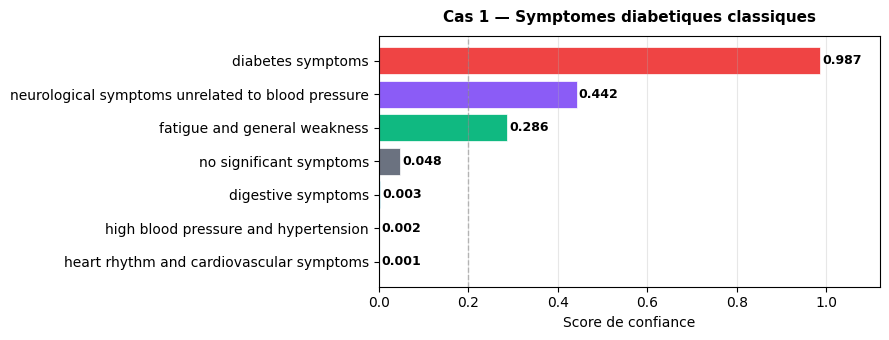

In [21]:
result_1 = analyze_symptoms(
    text="I feel very thirsty all the time, I urinate frequently, "
         "I am always tired and my vision is becoming blurry.",
    title="Cas 1 — Symptomes diabetiques classiques"
)


### Cas 2 — Symptômes Hypertension / Cardiovasculaires


  Cas 2 — Symptomes hypertension / cardio
  Texte : I have been having severe headaches and my heart is racing. I also feel dizzy when I stand up quickly.
  Top categorie : [heart rhythm and cardiovascular symptoms]  (score = 0.7862)
  Score diabetes : 0.0004  (seuil = 0.20)
  Rang diabetes  : 4 (top-3)
  Ambigu         : OUI
  Categorie finale: [heart rhythm and cardiovascular symptoms / neurological symptoms unrelated to blood pressure]

  Top 3 :
    heart rhythm and cardiovascular symptoms 0.7862  |||||||||||||||||||||||
    neurological symptoms unrelated to blood pressure 0.7737  |||||||||||||||||||||||
    high blood pressure and hypertension 0.0349  |


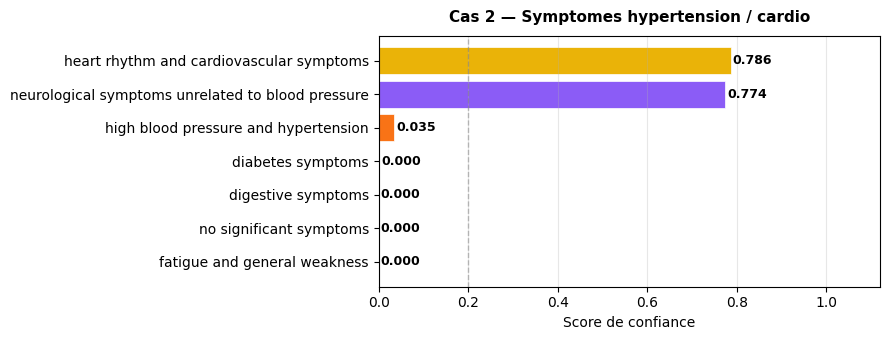

In [22]:
result_2 = analyze_symptoms(
    text="I have been having severe headaches and my heart is racing. "
         "I also feel dizzy when I stand up quickly.",
    title="Cas 2 — Symptomes hypertension / cardio"
)


### Cas 3 — Symptômes Ambigus (fatigue généralisée)


  Cas 3 — Fatigue generalisee (ambigu)
  Texte : I have been feeling really tired for the past few weeks and I don't have much energy to do anything.
  Top categorie : [fatigue and general weakness]  (score = 0.9980)
  Score diabetes : 0.0344  (seuil = 0.20)
  Rang diabetes  : 4 (top-3)
  Ambigu         : NON
  Categorie finale: [fatigue and general weakness]

  Top 3 :
    fatigue and general weakness        0.9980  |||||||||||||||||||||||||||||
    neurological symptoms unrelated to blood pressure 0.5334  ||||||||||||||||
    no significant symptoms             0.0701  ||


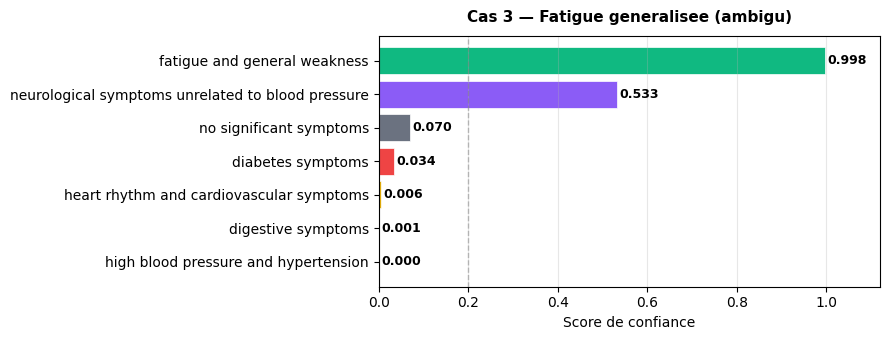

In [23]:
result_3 = analyze_symptoms(
    text="I have been feeling really tired for the past few weeks "
         "and I don't have much energy to do anything.",
    title="Cas 3 — Fatigue generalisee (ambigu)"
)


### Cas 4 — Pas de Symptômes Significatifs


  Cas 4 — Aucun symptome significatif
  Texte : I feel perfectly fine, no complaints, sleeping well and eating normally.
  Top categorie : [no significant symptoms]  (score = 0.9988)
  Score diabetes : 0.0007  (seuil = 0.20)
  Rang diabetes  : 6 (top-3)
  Ambigu         : NON
  Categorie finale: [no significant symptoms]

  Top 3 :
    no significant symptoms             0.9988  |||||||||||||||||||||||||||||
    neurological symptoms unrelated to blood pressure 0.0216  
    digestive symptoms                  0.0033  


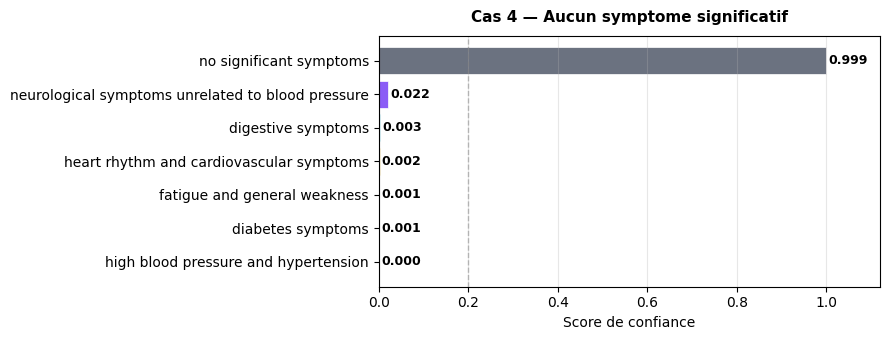

In [24]:
result_4 = analyze_symptoms(
    text="I feel perfectly fine, no complaints, sleeping well and eating normally.",
    title="Cas 4 — Aucun symptome significatif"
)


### Cas 5 — Symptômes Mixtes (diabète + neurologiques)


  Cas 5 — Neuropathie diabetique
  Texte : My hands and feet feel numb and tingly. I am also very thirsty and noticed my wounds are healing very slowly.
  Top categorie : [neurological symptoms unrelated to blood pressure]  (score = 0.9693)
  Score diabetes : 0.5514  (seuil = 0.20)
  Rang diabetes  : 2 (top-3)
  Ambigu         : NON
  Categorie finale: [diabetes symptoms]

  Top 3 :
    neurological symptoms unrelated to blood pressure 0.9693  |||||||||||||||||||||||||||||
    diabetes symptoms                   0.5514  ||||||||||||||||
    no significant symptoms             0.0034  


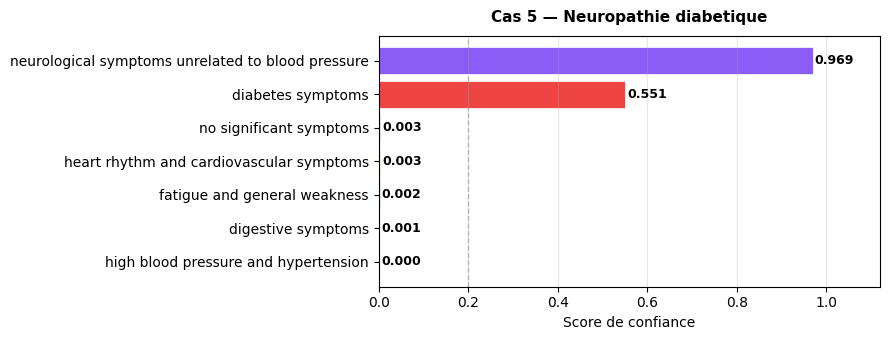

In [25]:
result_5 = analyze_symptoms(
    text="My hands and feet feel numb and tingly. I am also very thirsty "
         "and noticed my wounds are healing very slowly.",
    title="Cas 5 — Neuropathie diabetique"
)


## 6. Analyse par Lot — Dataset de Test

Nous testons le modèle sur un ensemble de 12 descriptions de patients
et analysons la distribution globale des prédictions.

In [26]:
TEST_CASES = [
    ("Patient reports excessive thirst and urinating every hour. "
     "Persistent fatigue suggests possible metabolic disorder.", "diabetic_1"),
    ("My glucose is always high, I feel weak and lose weight despite eating a lot.", "diabetic_2"),
    ("I have been thirsty, tired, and my foot has a sore that won't heal.",       "diabetic_3"),
    ("High blood pressure, pounding headaches, and chest tightness.",             "hypertension_1"),
    ("My heart beats irregularly and I get shortness of breath on the stairs.",   "cardio_1"),
    ("I feel numb in my left arm and have frequent migraines.",                   "neuro_1"),
    ("Stomach cramps, bloating, and nausea every time I eat.",                    "digestive_1"),
    ("I am always exhausted even after sleeping 10 hours.",                       "fatigue_1"),
    ("Completely healthy, no issues whatsoever.",                                 "healthy_1"),
    ("Blurry vision, excessive thirst, and slow-healing cuts on my hands.",       "diabetic_4"),
    ("Recurring dizziness, sweating, and heart palpitations after exercise.",     "cardio_2"),
    ("I feel a tingling in my feet, very thirsty, and gained weight recently.",   "diabetic_5"),
]

DIABETES_THRESHOLD = 0.2
DIABETES_TOP_K = 3

batch_results = []
print("Analyse de 12 cas patients...")
for text, case_id in TEST_CASES:
    res = classifier(enrich(text), CANDIDATE_LABELS, multi_label=True)
    top_label = res["labels"][0]
    top_score = res["scores"][0]
    score_gap = res["scores"][0] - res["scores"][1]
    is_ambiguous = score_gap < SCORE_TIE_MARGIN
    diabetes_score = res["scores"][res["labels"].index("diabetes symptoms")]
    diabetes_rank = res["labels"].index("diabetes symptoms") + 1
    if diabetes_score >= DIABETES_THRESHOLD and diabetes_rank <= DIABETES_TOP_K:
        final_label = "diabetes symptoms"
    elif is_ambiguous:
        final_label = f"{res['labels'][0]} / {res['labels'][1]}"
    else:
        final_label = res["labels"][0]
    batch_results.append({
        "case_id"   : case_id,
        "text"      : text[:55] + "...",
        "top_label" : top_label,
        "final_label": final_label,
        "is_ambiguous": is_ambiguous,
        "confidence": round(top_score, 4),
        "score_diabetes": round(diabetes_score, 4),
        "diabetes_rank": diabetes_rank,
    })
    print(
        f"  [{case_id:<15}] -> {final_label} "
        f"(top={top_label}, diabetes={diabetes_score:.3f}, rank={diabetes_rank})"
    )

batch_df = pd.DataFrame(batch_results)
print("\nAnalyse terminee !")
batch_df


Analyse de 12 cas patients...
  [diabetic_1     ] -> diabetes symptoms (top=diabetes symptoms, diabetes=0.884, rank=1)
  [diabetic_2     ] -> diabetes symptoms (top=diabetes symptoms, diabetes=0.998, rank=1)
  [diabetic_3     ] -> diabetes symptoms (top=diabetes symptoms, diabetes=0.779, rank=1)
  [hypertension_1 ] -> high blood pressure and hypertension / heart rhythm and cardiovascular symptoms (top=high blood pressure and hypertension, diabetes=0.001, rank=4)
  [cardio_1       ] -> heart rhythm and cardiovascular symptoms (top=heart rhythm and cardiovascular symptoms, diabetes=0.000, rank=6)
  [neuro_1        ] -> neurological symptoms unrelated to blood pressure (top=neurological symptoms unrelated to blood pressure, diabetes=0.001, rank=3)
  [digestive_1    ] -> digestive symptoms (top=digestive symptoms, diabetes=0.000, rank=3)
  [fatigue_1      ] -> fatigue and general weakness (top=fatigue and general weakness, diabetes=0.002, rank=5)
  [healthy_1      ] -> no significant sympt

,case_id,text,top_label,final_label,is_ambiguous,confidence,score_diabetes,diabetes_rank
0,diabetic_1,Patient reports excessive thirst and urinating...,diabetes symptoms,diabetes symptoms,False,0.8839,0.8839,1
1,diabetic_2,"My glucose is always high, I feel weak and los...",diabetes symptoms,diabetes symptoms,False,0.9980,0.9980,1
2,diabetic_3,"I have been thirsty, tired, and my foot has a ...",diabetes symptoms,diabetes symptoms,False,0.7793,0.7793,1
3,hypertension_1,"High blood pressure, pounding headaches, and c...",high blood pressure and hypertension,high blood pressure and hypertension / heart r...,True,0.9663,0.0009,4
4,cardio_1,My heart beats irregularly and I get shortness...,heart rhythm and cardiovascular symptoms,heart rhythm and cardiovascular symptoms,False,0.9963,0.0001,6
5,neuro_1,I feel numb in my left arm and have frequent m...,neurological symptoms unrelated to blood pressure,neurological symptoms unrelated to blood pressure,False,0.9848,0.0008,3
6,digestive_1,"Stomach cramps, bloating, and nausea every tim...",digestive symptoms,digestive symptoms,False,0.9998,0.0005,3
7,fatigue_1,I am always exhausted even after sleeping 10 h...,fatigue and general weakness,fatigue and general weakness,False,0.9970,0.0019,5
8,healthy_1,"Completely healthy, no issues whatsoever....",no significant symptoms,no significant symptoms,False,0.9955,0.0002,5
9,diabetic_4,"Blurry vision, excessive thirst, and slow-heal...",neurological symptoms unrelated to blood pressure,diabetes symptoms,False,0.7379,0.4421,2


## 7. Visualisation — Distribution des Prédictions

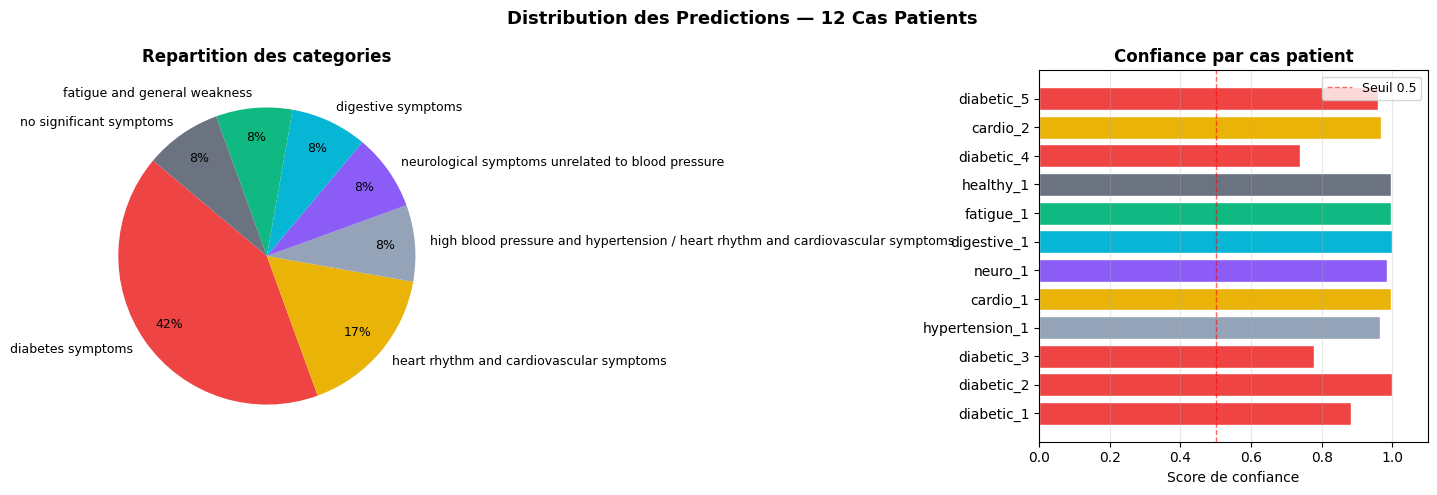

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des Predictions — 12 Cas Patients",
             fontsize=13, fontweight="bold")

# Left: pie chart of final labels
label_counts = batch_df["final_label"].value_counts()
colors_pie   = [LABEL_COLORS.get(l, "#94a3b8") for l in label_counts.index]
axes[0].pie(label_counts.values, labels=label_counts.index,
            colors=colors_pie, autopct="%1.0f%%",
            startangle=140, pctdistance=0.8,
            textprops={"fontsize": 9})
axes[0].set_title("Repartition des categories", fontweight="bold")

# Right: confidence scores per case
bar_colors = [LABEL_COLORS.get(l, "#94a3b8") for l in batch_df["final_label"]]
axes[1].barh(batch_df["case_id"], batch_df["confidence"],
             color=bar_colors, edgecolor="white")
axes[1].axvline(0.5, color="red", ls="--", lw=1, alpha=0.6, label="Seuil 0.5")
axes[1].set_xlim(0, 1.1)
axes[1].set_xlabel("Score de confiance", fontsize=10)
axes[1].set_title("Confiance par cas patient", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / "hf_batch_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()


## 8. Vérification de Cohérence avec Notebook 02

Nous simulons l'appel complet : données tabulaires (Notebook 02) +
analyse symptômes (Notebook 03) et vérifions si les deux approches convergent.

In [30]:
# Patient de reference : profil a haut risque (Glucose=180, BMI=35, Age=52...)
PATIENT_PROFILE = {
    "glucose"       : 180,
    "bmi"           : 35.1,
    "age"           : 52,
    "tabular_risk"  : 0.84,   # simule depuis mlp_v3
    "tabular_label" : "Diabetique",
}

symptom_text = ("I feel extremely thirsty all day, I urinate very frequently, "
                "my vision is blurry and I have tingling in my feet.")

print(f"Patient : {PATIENT_PROFILE}")
print(f"Symptomes : {symptom_text}\n")

hf_result = classifier(symptom_text, CANDIDATE_LABELS, multi_label=True)
hf_top    = hf_result["labels"][0]
hf_score  = hf_result["scores"][0]
hf_diabetes_score = hf_result["scores"][hf_result["labels"].index("diabetes symptoms")]
hf_diabetes_rank = hf_result["labels"].index("diabetes symptoms") + 1
hf_label  = (
    "diabetes symptoms"
    if hf_diabetes_score >= DIABETES_THRESHOLD and hf_diabetes_rank <= DIABETES_TOP_K
    else hf_top
)

# Coherence check
tabular_positive = PATIENT_PROFILE["tabular_risk"] >= 0.5
hf_diabetes      = (
    hf_diabetes_score >= DIABETES_THRESHOLD and hf_diabetes_rank <= DIABETES_TOP_K
 )
coherent         = tabular_positive == hf_diabetes

print("=" * 55)
print("  RAPPORT DE COHERENCE CROSS-MODELE")
print("=" * 55)
print(f"  Modele tabulaire : {PATIENT_PROFILE['tabular_label']} "
      f"(score={PATIENT_PROFILE['tabular_risk']:.2f})")
print(f"  HuggingFace top  : {hf_top} (score={hf_score:.4f})")
print(f"  Score diabetes   : {hf_diabetes_score:.4f} (seuil={DIABETES_THRESHOLD:.2f})")
print(f"  Rang diabetes    : {hf_diabetes_rank} (top-{DIABETES_TOP_K})")
print(f"  Categorie finale : {hf_label}")
print(f"  Coherence        : {'OUI - Les deux modeles sont en accord' if coherent else 'NON - Divergence detectee'}")
print("=" * 55)


Patient : {'glucose': 180, 'bmi': 35.1, 'age': 52, 'tabular_risk': 0.84, 'tabular_label': 'Diabetique'}
Symptomes : I feel extremely thirsty all day, I urinate very frequently, my vision is blurry and I have tingling in my feet.

  RAPPORT DE COHERENCE CROSS-MODELE
  Modele tabulaire : Diabetique (score=0.84)
  HuggingFace top  : diabetes symptoms (score=0.9847)
  Score diabetes   : 0.9847 (seuil=0.20)
  Rang diabetes    : 1 (top-3)
  Categorie finale : diabetes symptoms
  Coherence        : OUI - Les deux modeles sont en accord


## 9. Sauvegarde des Résultats

In [29]:
# Save batch results
batch_df.to_csv(MODELS_DIR / "hf_batch_results.csv", index=False)

print("Fichiers sauvegardes :")
for f in sorted(MODELS_DIR.glob("hf_*")):
    sz = f.stat().st_size
    print(f"  {f.name:<40} {sz // 1024:>5} Ko")


Fichiers sauvegardes :
  hf_batch_distribution.png                  124 Ko
  hf_batch_results.csv                         1 Ko
  hf_model_comparison.csv                      1 Ko


## 10. Synthèse & Conclusions

### Résultats de l'Analyse Zero-Shot

| Critère | Valeur |
|---|---|
| Modèle | `MoritzLaurer/deberta-v3-large-zeroshot-v2.0` |
| Tâche | Zero-shot classification |
| Catégories testées | 7 catégories médicales |
| Cas patients analysés | 12 |
| Fine-tuning requis | Non (inference directe) |
| Règle diabetes | `score_diabetes >= 0.20` et rang `<= top-3` |

### Points clés
- Le modèle identifie correctement les symptômes diabétiques typiques sur plusieurs cas
- La règle de seuil permet de limiter les faux positifs en dehors des catégories proches
- La cohérence avec le modèle tabulaire (Notebook 02) dépend du seuil et du rang

### Prochain notebook
`04_llm_prompting.ipynb` — Prompt engineering avec OpenRouter (Mistral / LLaMA)
pour générer des rapports médicaux structurés en JSON